# TP4 — Gradient en ligne, sous-gradient en ligne, SGD, SSGD
**Cadre online · Cadre stochastique · Regret · Comparaison**

---
**Partie I** : Gradient en ligne — Régression polynomiale (California Housing)  
**Partie II** : Sous-gradient en ligne — Classification binaire (Breast Cancer)  
**Partie III** : SGD — Régression  
**Partie IV** : SSGD — Classification  
**Dépendances** : `utils.py`, `polynomial.py`, `perceptron.py`, `metrics.py`, `online.py`, `stochastic.py`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

sys.path.append(os.path.abspath('..'))

from utils import train_val_test_split, standardize, print_table, adaptive_epsilon_schedule
from TP1.polynomial import (
    phi, predict as poly_predict, mse, r2_score,
    gradient_descent, plot_convergence as poly_plot_conv
)
from TP2.perceptron import (
    predict, hinge_loss, subgradient_descent, poly_features
)
from TP2.metrics import accuracy, classification_report, f1_score
from online import (
    online_gradient_regression, compare_steps_online_regression,
    online_subgradient_classification, compare_steps_online_classification,
    estimate_regret, compute_best_fixed_regression,
    compute_best_fixed_classification,
    plot_instant_losses, plot_cumulative_losses,
    plot_regrets, plot_cumul_errors, plot_online_vs_batch
)
from stochastic import (
    sgd_regression, compare_sgd_regression,
    ssgd_classification, compare_ssgd_classification,
    sgd_vs_full_regression, sgd_vs_full_classification,
    plot_sgd_comparison, plot_sgd_vs_full,
    plot_variance, plot_step_evolution
)

plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


In [2]:
from sklearn.datasets import fetch_california_housing, load_breast_cancer

# ── Régression ──
housing = fetch_california_housing()
X_reg_raw, y_reg = housing.data[:, 0], housing.target
X_reg_tr, y_reg_tr, X_reg_val, y_reg_val, X_reg_te, y_reg_te = \
    train_val_test_split(X_reg_raw, y_reg, val_ratio=0.1, test_ratio=0.15, seed=SEED)
[X_reg_tr_s, X_reg_val_s, X_reg_te_s], _, _ = standardize(X_reg_tr, X_reg_val, X_reg_te)
D_REG = 3

# ── Classification ──
data = load_breast_cancer()
X_clf_raw = data.data
y_clf = np.where(data.target == 1, 1, -1)
X_clf_tr, y_clf_tr, X_clf_val, y_clf_val, X_clf_te, y_clf_te = \
    train_val_test_split(X_clf_raw, y_clf, val_ratio=0.1, test_ratio=0.15, seed=SEED)
[X_clf_tr_s, X_clf_val_s, X_clf_te_s], _, _ = standardize(X_clf_tr, X_clf_val, X_clf_te)

print(f'Régression  — Train: {len(y_reg_tr)}')
print(f'Classif.    — Train: {len(y_clf_tr)}')

Régression  — Train: 15480
Classif.    — Train: 428


---
# Partie I — Gradient en ligne (Régression)
**Questions OGD-R.1 → OGD-R.10**

/home/aymane/Documents/Projects/tps_ml/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/home/aymane/Documents/Projects/tps_ml/TP4/online.py:87: RuntimeWarning: overflow encountered in scalar power
  loss_t = (y_hat - y[t]) ** 2
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:125: RuntimeWarning: overflow encountered in multiply
  return 2.0 * residual * phi_i
/home/aymane/Documents/Projects/tps_ml/TP4/online.py:86: RuntimeWarning: invalid value encountered in matmul
  y_hat = phi(X[t], d) @ theta
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:124: RuntimeWarning: invalid value encountered in matmul
  residual = phi_i @ theta - yi


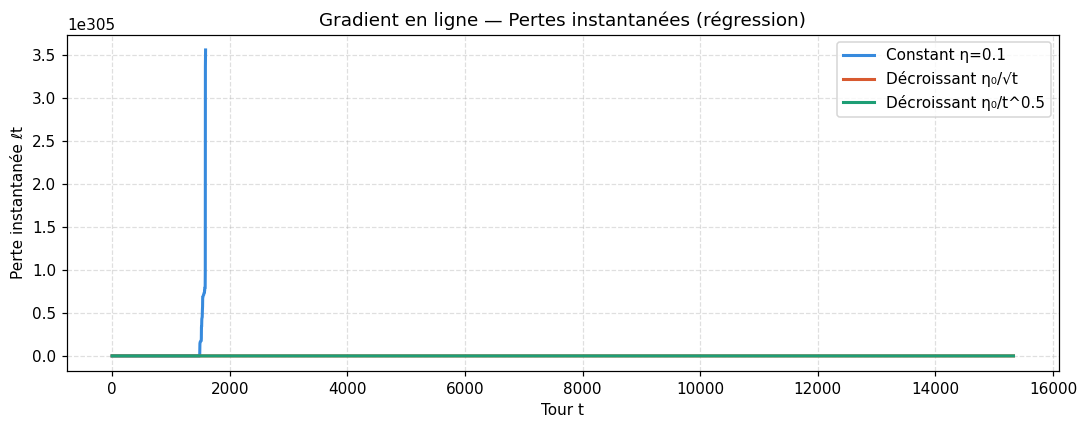

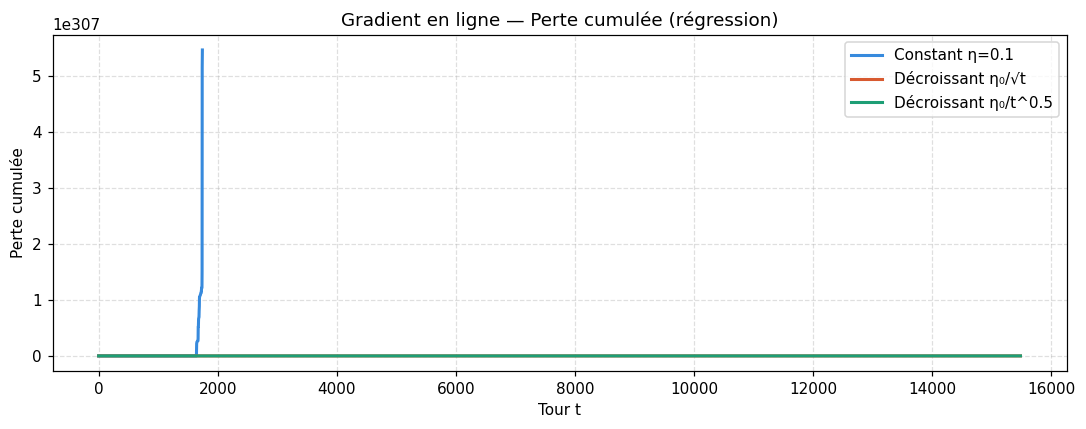

In [3]:
# OGD-R.4→R.5 — Gradient en ligne avec 3 suites de pas
results_ogd_reg = compare_steps_online_regression(
    X_reg_tr_s, y_reg_tr, d=D_REG, eta0=0.1
)

# OGD-R.6 — Pertes instantanées
fig = plot_instant_losses(results_ogd_reg,
    title='Gradient en ligne — Pertes instantanées (régression)')
plt.savefig('../outputs/figures/TP4_01_ogd_reg_instant.png', bbox_inches='tight')
plt.show()

# OGD-R.7 — Perte cumulée
fig = plot_cumulative_losses(results_ogd_reg,
    title='Gradient en ligne — Perte cumulée (régression)')
plt.savefig('../outputs/figures/TP4_02_ogd_reg_cumul.png', bbox_inches='tight')
plt.show()

Perte du meilleur prédicteur fixe (batch) : 0.690276


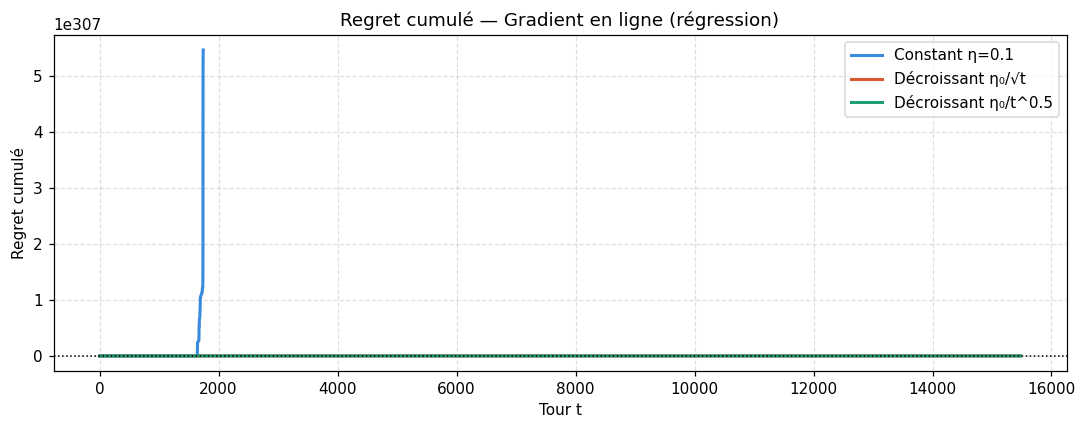

In [4]:
# OGD-R.8 — Estimation du regret
best_loss = compute_best_fixed_regression(
    X_reg_tr_s, y_reg_tr, D_REG, n_iter=3000, eta=0.005
)
print(f'Perte du meilleur prédicteur fixe (batch) : {best_loss:.6f}')

regrets = {}
for label, hist in results_ogd_reg.items():
    regrets[label] = estimate_regret(hist['cumul_loss'], best_loss)

fig = plot_regrets(regrets, title='Regret cumulé — Gradient en ligne (régression)')
plt.savefig('../outputs/figures/TP4_03_ogd_reg_regret.png', bbox_inches='tight')
plt.show()

/home/aymane/Documents/Projects/tps_ml/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:86: RuntimeWarning: overflow encountered in square
  return float(np.mean(residuals ** 2))
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:114: RuntimeWarning: overflow encountered in matmul
  return (2.0 / len(y)) * Phi.T @ residuals
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:114: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / len(y)) * Phi.T @ residuals
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:166: RuntimeWarning: invalid value encountered in subtract
  theta = theta - alpha * g


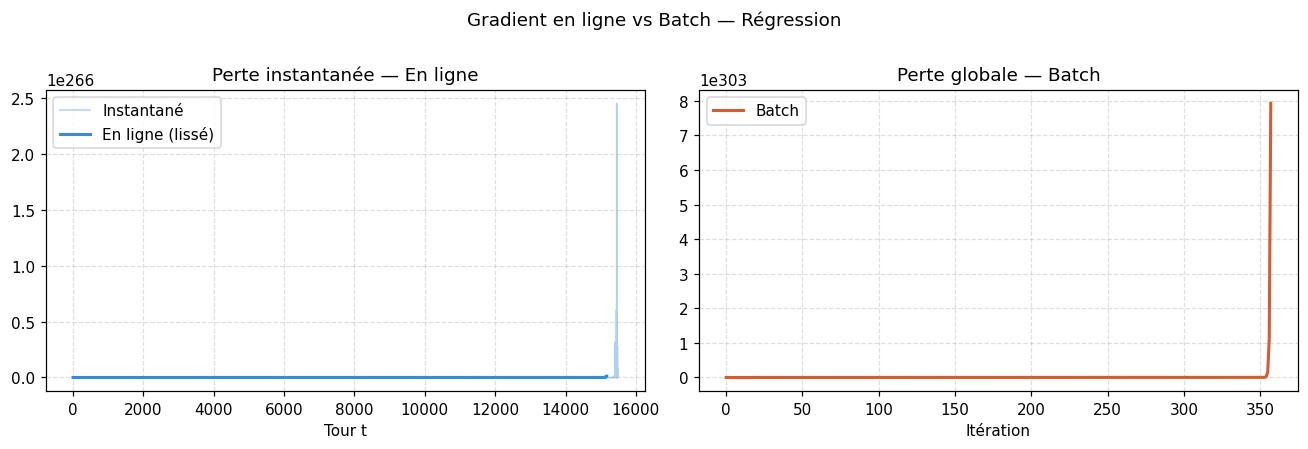

Méthode               MSE Train                                                                                                                                                                                                                                                                         MSE Test                                                                                                                                                                                                                                                                          Regret final                                                                                                                                                                                                                                                                  
--------------------  -----------------------------------------------------------------------------------------------------------------------------------------

In [5]:
# OGD-R.10 — Online vs Batch
_, hist_online_reg = online_gradient_regression(
    X_reg_tr_s, y_reg_tr, d=D_REG, eta0=0.1, decay='sqrt'
)
_, hist_batch_reg = gradient_descent(
    X_reg_tr_s, y_reg_tr, D_REG, alpha=0.01, n_iter=len(y_reg_tr)
)

fig = plot_online_vs_batch(
    hist_online_reg, hist_batch_reg['cost'],
    title='Gradient en ligne vs Batch — Régression'
)
plt.savefig('../outputs/figures/TP4_04_ogd_vs_batch_reg.png', bbox_inches='tight')
plt.show()

# Tableau récap
headers = ['Méthode', 'MSE Train', 'MSE Test', 'Regret final']
table = []
for label, hist in results_ogd_reg.items():
    # Dernier theta (approximation)
    theta_final = hist['theta_list'][-1]
    mse_tr = mse(theta_final, X_reg_tr_s, y_reg_tr, D_REG)
    mse_te = mse(theta_final, X_reg_te_s, y_reg_te, D_REG)
    reg_final = regrets[label][-1]
    table.append([label, f'{mse_tr:.4f}', f'{mse_te:.4f}', f'{reg_final:.2f}'])
print_table(table, headers)

---
# Partie II — Sous-gradient en ligne (Classification)
**Questions OSD-C.1 → OSD-C.10**

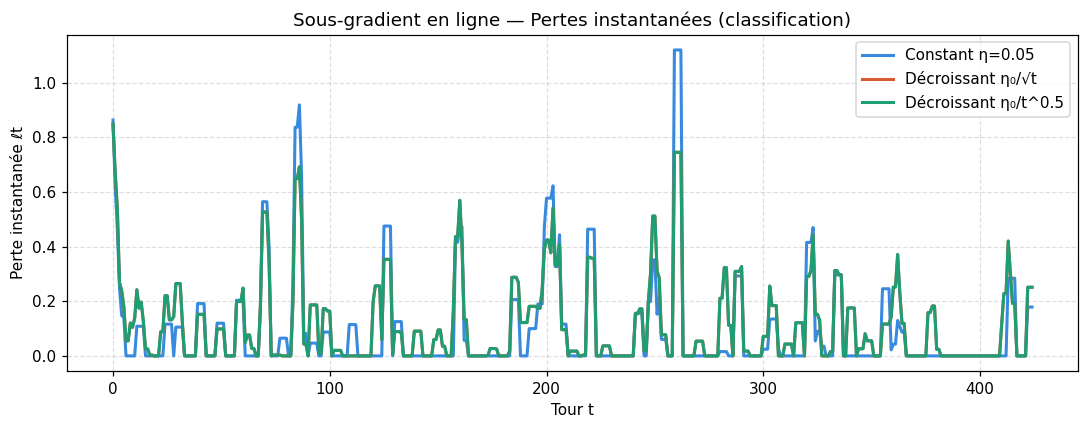

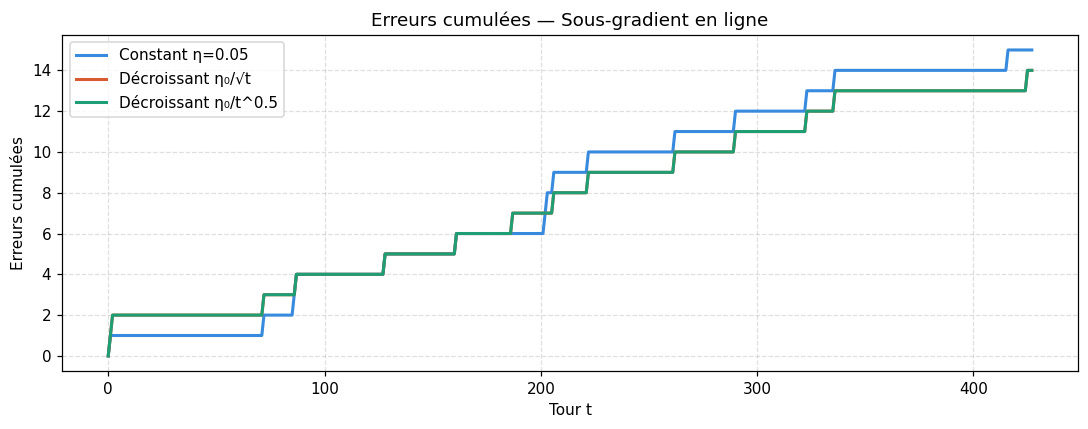

In [6]:
# OSD-C.4→C.5 — Sous-gradient en ligne avec 3 suites de pas
results_osd_clf = compare_steps_online_classification(
    X_clf_tr_s, y_clf_tr, eta0=0.05
)

fig = plot_instant_losses(results_osd_clf,
    title='Sous-gradient en ligne — Pertes instantanées (classification)')
plt.savefig('../outputs/figures/TP4_05_osd_clf_instant.png', bbox_inches='tight')
plt.show()

fig = plot_cumul_errors(results_osd_clf,
    title='Erreurs cumulées — Sous-gradient en ligne')
plt.savefig('../outputs/figures/TP4_06_osd_clf_errors.png', bbox_inches='tight')
plt.show()

Perte hinge du meilleur prédicteur fixe : 0.031533


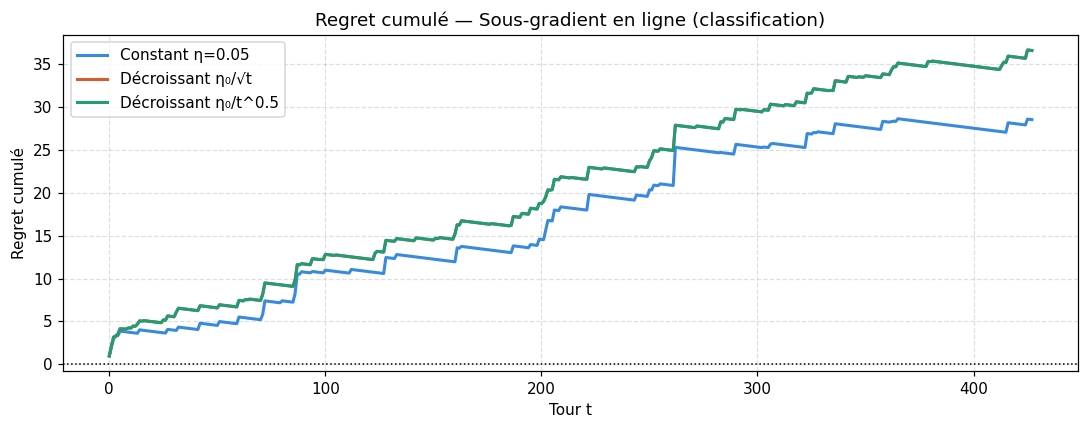

In [7]:
# OSD-C.7 — Regret
best_loss_clf = compute_best_fixed_classification(
    X_clf_tr_s, y_clf_tr, alpha=0.005, n_iter=3000
)
print(f'Perte hinge du meilleur prédicteur fixe : {best_loss_clf:.6f}')

regrets_clf = {}
for label, hist in results_osd_clf.items():
    regrets_clf[label] = estimate_regret(hist['cumul_loss'], best_loss_clf)

fig = plot_regrets(regrets_clf,
    title='Regret cumulé — Sous-gradient en ligne (classification)')
plt.savefig('../outputs/figures/TP4_07_osd_clf_regret.png', bbox_inches='tight')
plt.show()

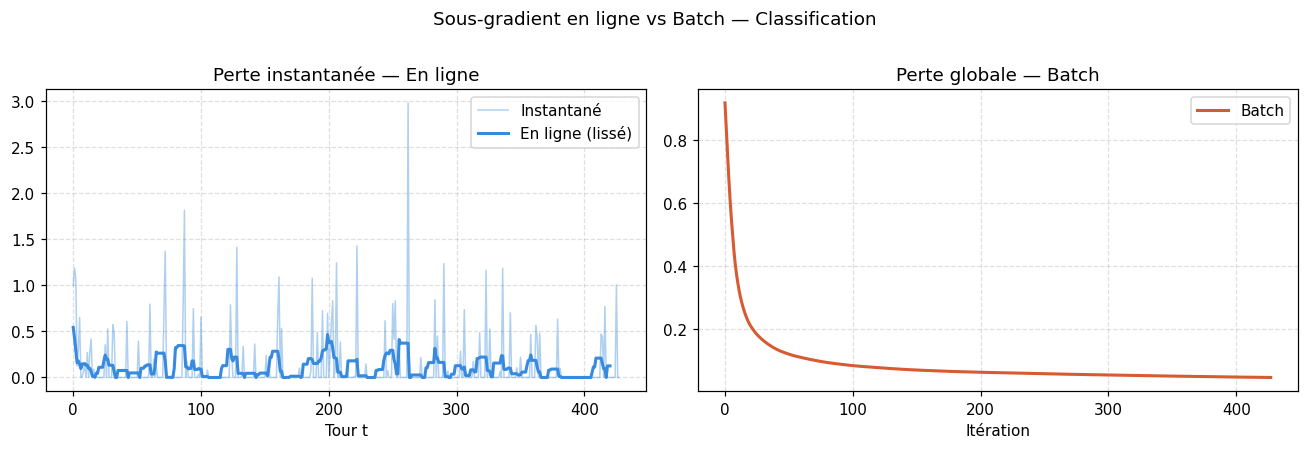

Méthode               Perte finale  Regret final  Erreurs totales
--------------------  ------------  ------------  ---------------
Constant η=0.05       0.0982        28.55         15             
Décroissant η₀/√t     0.1171        36.62         14             
Décroissant η₀/t^0.5  0.1171        36.62         14             


In [8]:
# OSD-C.10 — Online vs Batch
_, _, hist_online_clf = online_subgradient_classification(
    X_clf_tr_s, y_clf_tr, eta0=0.05, decay='sqrt'
)
_, _, hist_batch_clf = subgradient_descent(
    X_clf_tr_s, y_clf_tr, alpha=0.01,
    n_iter=len(y_clf_tr), loss='hinge'
)

fig = plot_online_vs_batch(
    hist_online_clf, hist_batch_clf['cost'],
    title='Sous-gradient en ligne vs Batch — Classification'
)
plt.savefig('../outputs/figures/TP4_08_osd_vs_batch_clf.png', bbox_inches='tight')
plt.show()

# Tableau récap classification
headers = ['Méthode', 'Perte finale', 'Regret final', 'Erreurs totales']
table = []
for label, hist in results_osd_clf.items():
    table.append([
        label,
        f"{hist['cumul_loss'][-1] / len(y_clf_tr):.4f}",
        f"{regrets_clf[label][-1]:.2f}",
        str(hist['cumul_errors'][-1])
    ])
print_table(table, headers)

---
# Partie III — Gradient stochastique (Régression)
**Questions SGD-R.1 → SGD-R.9**

/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:62: RuntimeWarning: overflow encountered in matmul
  return Phi @ theta
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:62: RuntimeWarning: invalid value encountered in matmul
  return Phi @ theta
/home/aymane/Documents/Projects/tps_ml/TP4/stochastic.py:89: RuntimeWarning: invalid value encountered in subtract
  theta = theta - step * g
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:134: RuntimeWarning: overflow encountered in matmul
  return (2.0 / len(y_batch)) * Phi.T @ residuals
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:134: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / len(y_batch)) * Phi.T @ residuals


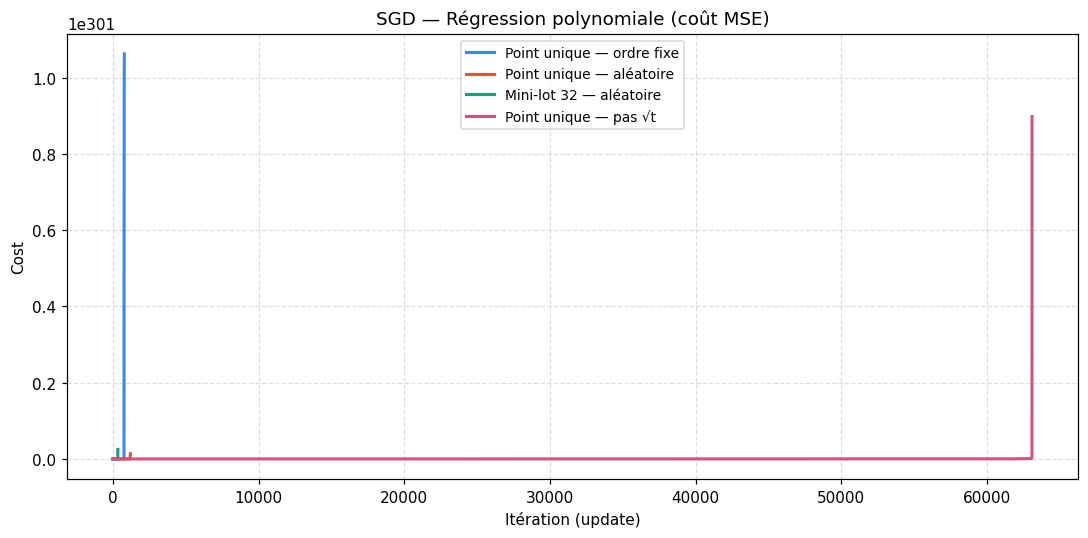

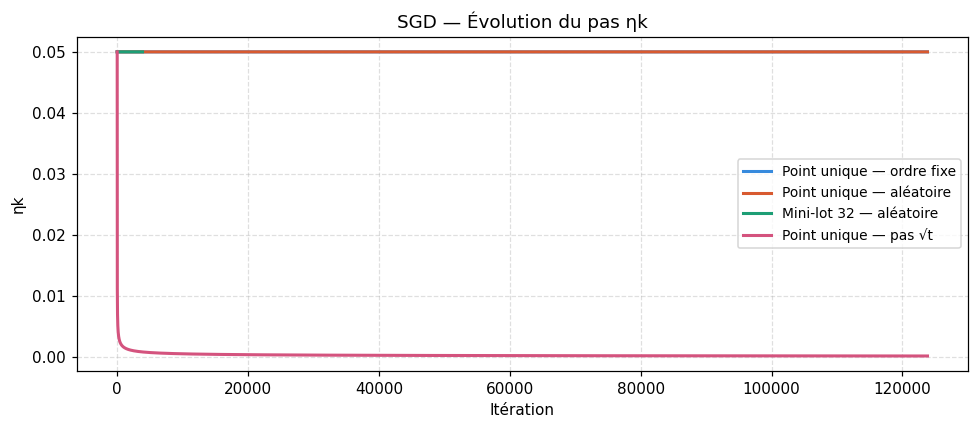

In [9]:
# SGD-R.3→R.5 — Comparaison des configurations SGD
results_sgd = compare_sgd_regression(
    X_reg_tr_s, y_reg_tr, d=D_REG, eta0=0.05,
    n_epochs=8, seed=SEED
)

fig = plot_sgd_comparison(results_sgd, metric='cost',
    title='SGD — Régression polynomiale (coût MSE)')
plt.savefig('../outputs/figures/TP4_09_sgd_reg_cost.png', bbox_inches='tight')
plt.show()

fig = plot_step_evolution(results_sgd,
    title='SGD — Évolution du pas ηk')
plt.savefig('../outputs/figures/TP4_10_sgd_reg_steps.png', bbox_inches='tight')
plt.show()

/home/aymane/Documents/Projects/tps_ml/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: overflow encountered in square
  x = um.square(x, out=x)
/home/aymane/Documents/Projects/tps_ml/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:201: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/home/aymane/Documents/Projects/tps_ml/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)


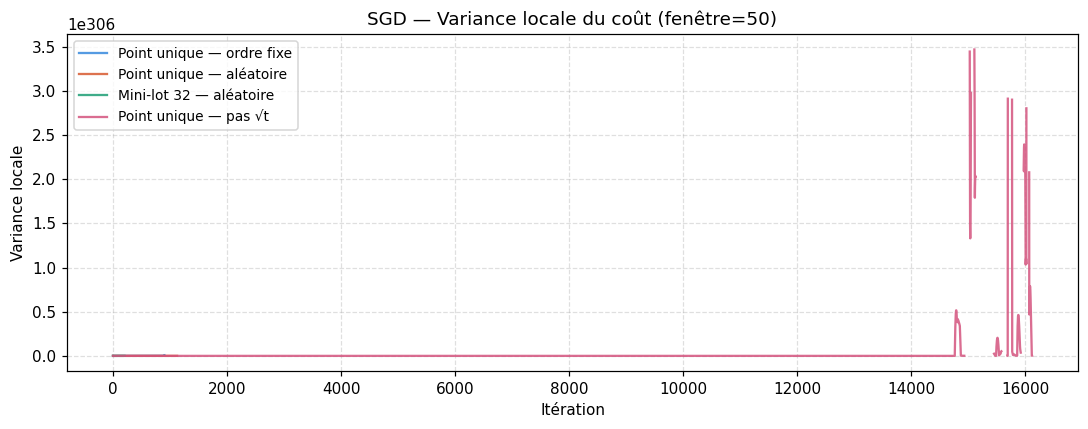

In [10]:
# SGD-R.8 — Variance des mises à jour
fig = plot_variance(results_sgd, metric='cost',
    title='SGD — Variance locale du coût (fenêtre=50)')
plt.savefig('../outputs/figures/TP4_11_sgd_reg_variance.png', bbox_inches='tight')
plt.show()

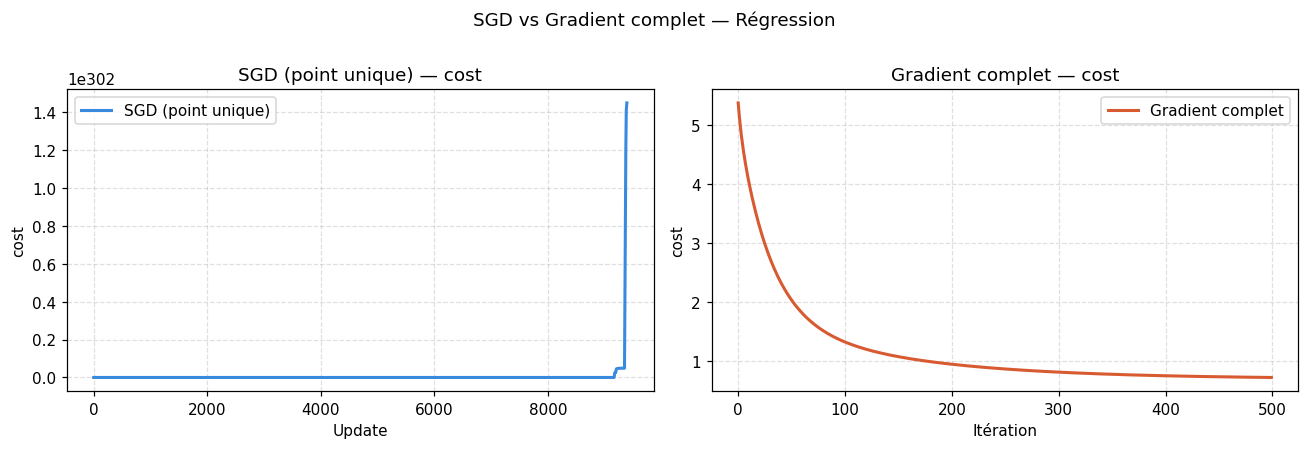

Configuration              MSE Train  MSE Test  R² Test
-------------------------  ---------  --------  -------
Point unique — ordre fixe  nan        nan       nan    
Point unique — aléatoire   nan        nan       nan    
Mini-lot 32 — aléatoire    nan        nan       nan    
Point unique — pas √t      inf        inf       -inf   


/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:222: RuntimeWarning: overflow encountered in square
  ss_res = np.sum((y - y_hat) ** 2)


In [11]:
# SGD-R.7 — SGD vs Gradient complet
hist_sgd_r, hist_full_r = sgd_vs_full_regression(
    X_reg_tr_s, y_reg_tr, D_REG, eta=0.005, seed=SEED
)

fig = plot_sgd_vs_full(
    hist_sgd_r, hist_full_r,
    label_sgd='SGD (point unique)',
    label_full='Gradient complet',
    title='SGD vs Gradient complet — Régression'
)
plt.savefig('../outputs/figures/TP4_12_sgd_vs_full_reg.png', bbox_inches='tight')
plt.show()

# Tableau récap SGD régression
headers = ['Configuration', 'MSE Train', 'MSE Test', 'R² Test']
table = []
for label, (theta, hist) in results_sgd.items():
    mse_tr = mse(theta, X_reg_tr_s, y_reg_tr, D_REG)
    mse_te = mse(theta, X_reg_te_s, y_reg_te, D_REG)
    r2_te  = r2_score(theta, X_reg_te_s, y_reg_te, D_REG)
    table.append([label, f'{mse_tr:.4f}', f'{mse_te:.4f}', f'{r2_te:.4f}'])
print_table(table, headers)

---
# Partie IV — Sous-gradient stochastique (Classification)
**Questions SSG-C.1 → SSG-C.9**

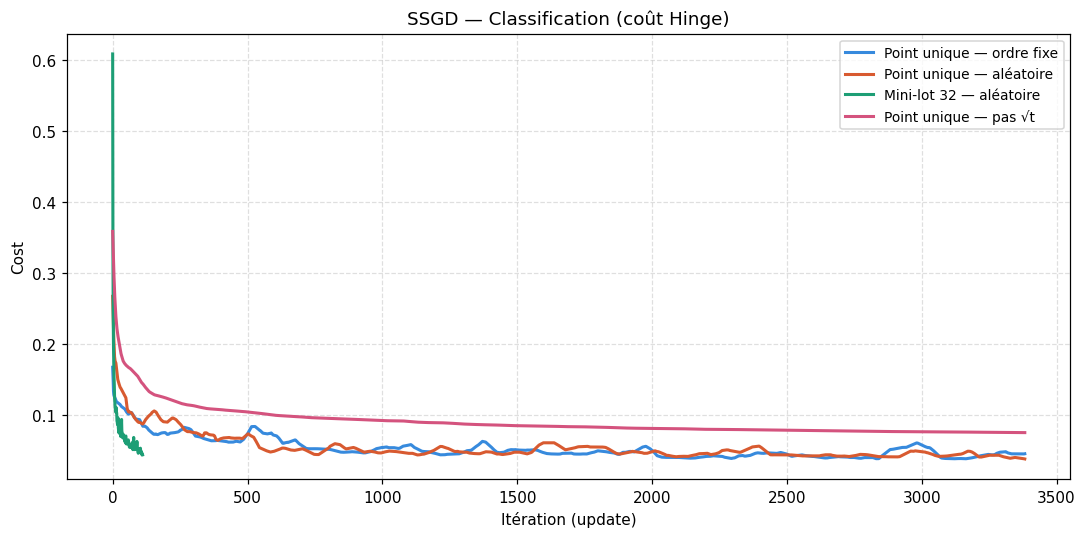

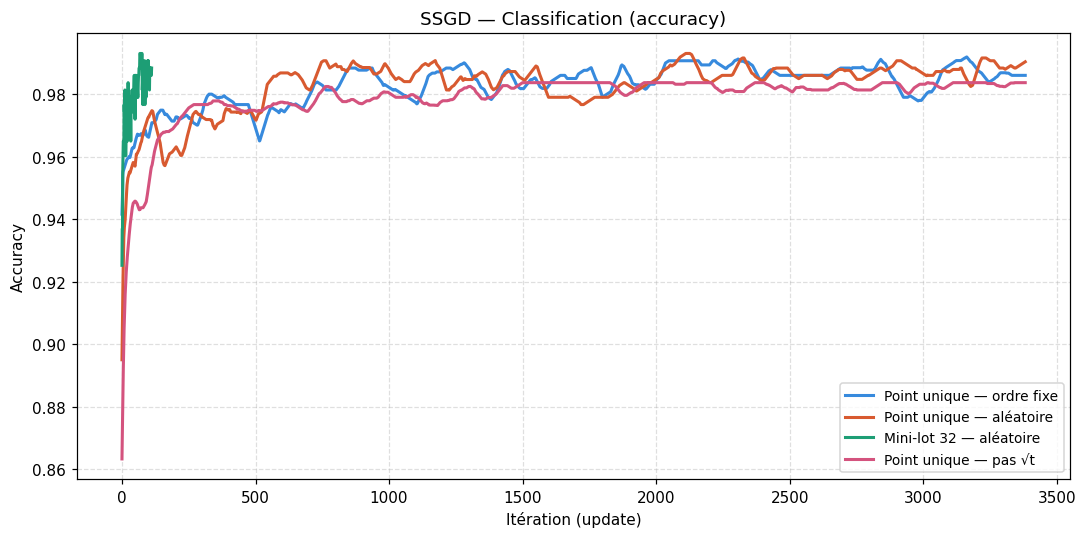

In [12]:
# SSG-C.3→C.5 — Comparaison des configurations SSGD
results_ssgd = compare_ssgd_classification(
    X_clf_tr_s, y_clf_tr, eta0=0.05,
    n_epochs=8, seed=SEED
)

fig = plot_sgd_comparison(results_ssgd, metric='cost',
    title='SSGD — Classification (coût Hinge)')
plt.savefig('../outputs/figures/TP4_13_ssgd_clf_cost.png', bbox_inches='tight')
plt.show()

fig = plot_sgd_comparison(results_ssgd, metric='accuracy',
    title='SSGD — Classification (accuracy)')
plt.savefig('../outputs/figures/TP4_14_ssgd_clf_accuracy.png', bbox_inches='tight')
plt.show()

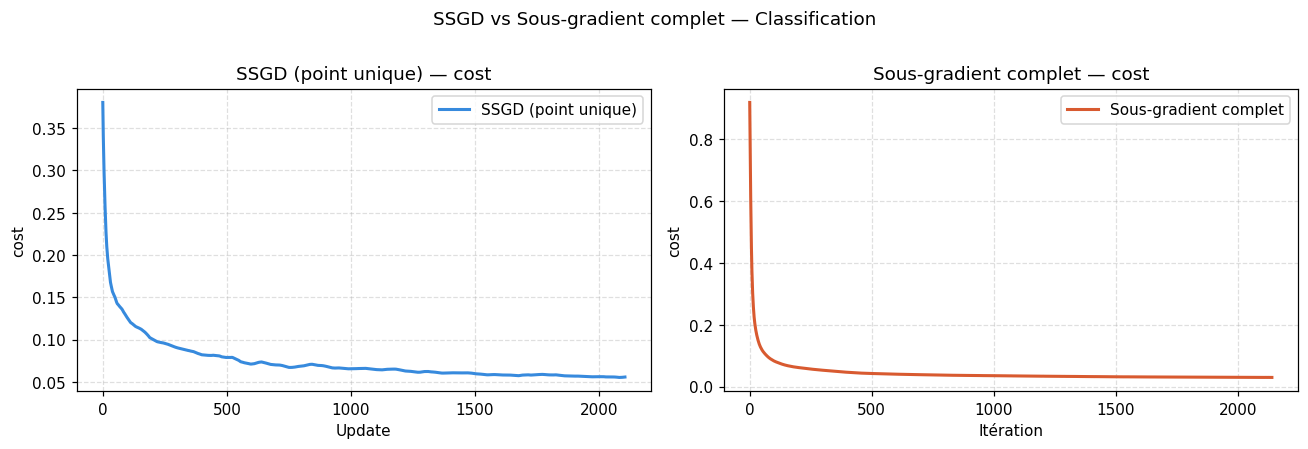

Configuration              Acc. Train  Acc. Test  F1 Test
-------------------------  ----------  ---------  -------
Point unique — ordre fixe  0.9860      0.9882     0.9913 
Point unique — aléatoire   0.9907      0.9765     0.9825 
Mini-lot 32 — aléatoire    0.9883      0.9765     0.9828 
Point unique — pas √t      0.9836      0.9647     0.9744 


In [13]:
# SSG-C.7 — SSGD vs Sous-gradient complet
hist_ssgd_c, hist_full_c = sgd_vs_full_classification(
    X_clf_tr_s, y_clf_tr, eta=0.01, n_epochs=5, seed=SEED
)

fig = plot_sgd_vs_full(
    hist_ssgd_c, hist_full_c,
    label_sgd='SSGD (point unique)',
    label_full='Sous-gradient complet',
    title='SSGD vs Sous-gradient complet — Classification'
)
plt.savefig('../outputs/figures/TP4_15_ssgd_vs_full_clf.png', bbox_inches='tight')
plt.show()

# SSG-C.9 — Tableau récap SSGD classification
headers = ['Configuration', 'Acc. Train', 'Acc. Test', 'F1 Test']
table = []
for label, (w, b, hist) in results_ssgd.items():
    acc_tr = accuracy(y_clf_tr, predict(w, b, X_clf_tr_s))
    acc_te = accuracy(y_clf_te, predict(w, b, X_clf_te_s))
    f1_te  = f1_score(y_clf_te, predict(w, b, X_clf_te_s))
    table.append([label, f'{acc_tr:.4f}', f'{acc_te:.4f}', f'{f1_te:.4f}'])
print_table(table, headers)

---
# Comparaison finale : Online vs Stochastique
**Questions C.1 → C.5**

## 5bis · Epsilon auto-adaptatif comme seuil de résolution
- Ici, $\epsilon_t$ est un seuil de tolérance / de résolution appliqué à une quantité observée (par exemple une perte lissée).
- $\epsilon_t$ est distinct du pas d’apprentissage $\eta_t$.
- Un $\epsilon$ fixe impose une résolution constante.
- Un $\epsilon$ auto-adaptatif décroît avec le temps et demande une précision plus fine au fil des itérations.

In [ ]:
eps_auto_hist = results_ogd_reg['Décroissant η₀/√t']
eps_auto_trace = np.array(eps_auto_hist['instant_loss'], dtype=float)
eps_auto_T = len(eps_auto_trace)
eps_auto_window = min(eps_auto_T, max(5, eps_auto_T // 40))
eps_auto_kernel = np.ones(eps_auto_window) / eps_auto_window
eps_auto_trace_smooth = np.convolve(eps_auto_trace, eps_auto_kernel, mode='same')

eps_auto_scale = max(np.quantile(eps_auto_trace_smooth, 0.8), 1e-8)
eps_auto_fixed = np.full(eps_auto_T, eps_auto_scale)
eps_auto_adapt = np.array([
    adaptive_epsilon_schedule(t=i + 1, scale=eps_auto_scale, mode='sqrt')
    for i in range(eps_auto_T)
])

eps_auto_ok_fixed = (eps_auto_trace_smooth <= eps_auto_fixed).astype(float)
eps_auto_ok_adapt = (eps_auto_trace_smooth <= eps_auto_adapt).astype(float)
eps_auto_frac_fixed = np.cumsum(eps_auto_ok_fixed) / np.arange(1, eps_auto_T + 1)
eps_auto_frac_adapt = np.cumsum(eps_auto_ok_adapt) / np.arange(1, eps_auto_T + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(eps_auto_trace_smooth, color='#378ADD', linewidth=2,
             label='Perte instantanée lissée')
axes[0].plot(eps_auto_fixed, color='#D85A30', linestyle='--', linewidth=2,
             label='ε fixe')
axes[0].plot(eps_auto_adapt, color='#1D9E75', linestyle='-.', linewidth=2,
             label='ε auto-adaptatif')
axes[0].set_xlabel('Itération t')
axes[0].set_ylabel('Valeur')
axes[0].set_title('Trace observée vs seuils ε')
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend()

axes[1].plot(eps_auto_frac_fixed, color='#D85A30', linewidth=2,
             label='Fraction cumulée sous ε fixe')
axes[1].plot(eps_auto_frac_adapt, color='#1D9E75', linewidth=2,
             label='Fraction cumulée sous ε auto-adaptatif')
axes[1].set_xlabel('Itération t')
axes[1].set_ylabel('Fraction cumulée de satisfaction')
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Satisfaction cumulée du critère')
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Interprétation :')
print('- ε fixe garde la même résolution pendant tout l’apprentissage.')
print('- ε auto-adaptatif devient plus exigeant avec le temps : la perte doit décroître davantage pour rester sous le seuil.')
print(f'- Histoire réutilisée : gradient en ligne régression, configuration Décroissant η₀/√t, T = {eps_auto_T}.')

In [14]:
# C.3 — Comparaison online vs stochastique
print('=' * 60)
print('COMPARAISON : Cadre Online vs Cadre Stochastique')
print('=' * 60)

headers = ['Aspect', 'Online', 'Stochastique']
table = [
    ['Données',       'Flux séquentiel (t=1..T)', 'Dataset fixe, multi-epochs'],
    ['Objectif',      'Minimiser regret',          'Minimiser coût global'],
    ['Mise à jour',   '1 exemple par tour',        '1 exemple ou mini-lot'],
    ['Convergence',   'Garantie de regret',        'Convergence vers optimum'],
    ['Pas',           'Souvent décroissant',       'Fixe ou décroissant'],
    ['Adaptabilité',  'S\'adapte aux dérives',     'Suppose distribution fixe'],
]
print_table(table, headers)

# C.4 — Différentiable vs non différentiable
print('\nDifférentiable (régression) vs Non différentiable (classification) :')
print('- Régression : gradient exact disponible → convergence plus stable')
print('- Classification : sous-gradient → oscillations plus marquées')
print('- Dans les deux cas, le pas décroissant améliore la stabilité finale')

# C.5 — Recommandations
print('\nRecommandations :')
print('- Dataset statique + grand n → SGD avec mini-lots (meilleur compromis)')
print('- Flux de données en temps réel → Online (adaptatif)')
print('- Besoin de garanties théoriques → Online + pas décroissant')

COMPARAISON : Cadre Online vs Cadre Stochastique
Aspect        Online                    Stochastique              
------------  ------------------------  --------------------------
Données       Flux séquentiel (t=1..T)  Dataset fixe, multi-epochs
Objectif      Minimiser regret          Minimiser coût global     
Mise à jour   1 exemple par tour        1 exemple ou mini-lot     
Convergence   Garantie de regret        Convergence vers optimum  
Pas           Souvent décroissant       Fixe ou décroissant       
Adaptabilité  S'adapte aux dérives      Suppose distribution fixe 

Différentiable (régression) vs Non différentiable (classification) :
- Régression : gradient exact disponible → convergence plus stable
- Classification : sous-gradient → oscillations plus marquées
- Dans les deux cas, le pas décroissant améliore la stabilité finale

Recommandations :
- Dataset statique + grand n → SGD avec mini-lots (meilleur compromis)
- Flux de données en temps réel → Online (adaptatif)
- Be

In [15]:
# Tableau comparatif global C.1 / C.2
print('\n=== Tableau comparatif — Méthodes en ligne (Régression) ===')
headers = ['Pas', 'Regret final', 'MSE Train', 'MSE Test']
table = []
for label, hist in results_ogd_reg.items():
    theta_f = hist['theta_list'][-1]
    table.append([
        label,
        f"{regrets[label][-1]:.2f}",
        f"{mse(theta_f, X_reg_tr_s, y_reg_tr, D_REG):.4f}",
        f"{mse(theta_f, X_reg_te_s, y_reg_te, D_REG):.4f}",
    ])
print_table(table, headers)

print('\n=== Tableau comparatif — Méthodes stochastiques (Classification) ===')
headers = ['Configuration', 'Acc. Test', 'F1 Test']
table = []
for label, (w, b, _) in results_ssgd.items():
    acc = accuracy(y_clf_te, predict(w, b, X_clf_te_s))
    f1  = f1_score(y_clf_te, predict(w, b, X_clf_te_s))
    table.append([label, f'{acc:.4f}', f'{f1:.4f}'])
print_table(table, headers)


=== Tableau comparatif — Méthodes en ligne (Régression) ===
Pas                   Regret final                                                                                                                                                                                                                                                                    MSE Train                                                                                                                                                                                                                                                                         MSE Test                                                                                                                                                                                                                                                                        
--------------------  ----------------------------------------------------------------------------